<a href="https://colab.research.google.com/github/glorenz1/MSE_Spring_2026/blob/main/Hackathon_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Here there are four Hackathon problems prepared by Richard (Yu) Liu and Sergei Kalinin.
- Please select **2** out of **4** problems for your in-class "mini-hackathon".

In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt


# Q-1: Interpolating a Sparse Phase Diagram

**Problem description:**

This is a simulated 2D phase diagram: the measured property of (bandgap, coercive field, ionic conductivity, etc.) as a function of parameters (temperature, composition, pressure, etc.).

The property itself is continuous in the phase diagram, but its 1st-derivative is discontinuous at the phase boundaries.

**Tasks:**

1. Using ChatGPT and your domain knowledge, suggest the domain in parameter space over which the function is defined.
2. Using ChatGPT and your domain knowledge, estimate how the function can behave across the parameter space (continuity, extrema, behavior at the edges)
3. Interpolate the property over the full composition space.
4. Compare at least two interpolation methods (e.g., linear, cubic, radial basis).
5. Quantify interpolation uncertainty using cross-validation.
6. Compare uncertainty to the mean square error



In [ ]:
# Measured (p1, p2) parameter pairs
xy = np.array([[0.77395605, 0.43887844],
       [0.85859792, 0.69736803],
       [0.09417735, 0.97562235],
       [0.7611397 , 0.78606431],
       [0.12811363, 0.45038594],
       [0.37079802, 0.92676499],
       [0.64386512, 0.82276161],
       [0.4434142 , 0.22723872],
       [0.55458479, 0.06381726],
       [0.82763117, 0.6316644 ],
       [0.75808774, 0.35452597],
       [0.97069802, 0.89312112],
       [0.7783835 , 0.19463871],
       [0.466721  , 0.04380377],
       [0.15428949, 0.68304895],
       [0.74476216, 0.96750973],
       [0.32582536, 0.37045971],
       [0.46955581, 0.18947136],
       [0.12992151, 0.47570493],
       [0.22690935, 0.66981399],
       [0.43715192, 0.8326782 ],
       [0.7002651 , 0.31236664],
       [0.8322598 , 0.80476436],
       [0.38747838, 0.2883281 ],
       [0.6824955 , 0.13975248],
       [0.1999082 , 0.00736227],
       [0.78692438, 0.66485086],
       [0.70516538, 0.78072903],
       [0.45891578, 0.5687412 ],
       [0.139797  , 0.11453007],
       [0.66840296, 0.47109621],
       [0.56523611, 0.76499886],
       [0.63471832, 0.5535794 ],
       [0.55920716, 0.3039501 ],
       [0.03081783, 0.43671739]])

NameError: name 'np' is not defined

In [ ]:
# # Measured properties corresponding to the parameter pairs above

P_meas = np.array([3.12767655, 2.69646584, 2.06816235, 2.04820471, 1.41774581,
       3.04612474, 2.53364197, 2.34977995, 1.85446029, 2.87615438,
       2.79939622, 2.85913196, 2.36494563, 1.84774248, 1.96575226,
       2.37555217, 1.43091456, 2.27810839, 1.54323973, 2.12702863,
       2.79308942, 2.48750609, 3.07641066, 1.92720037, 1.84069555,
       2.14516326, 1.93443675, 1.85282274, 1.56231561, 1.68040985,
       2.65628142, 2.01911448, 2.23605819, 2.73677409, 1.66478083])

In [ ]:
# Visualization of the measurement with noise:

plt.scatter(xy[:,0], xy[:,1], c=P_meas, edgecolors="k", s=45)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Continuous property with gradient-discontinuous phase boundaries + triple point")
plt.colorbar()
plt.show()

## Ground truth for benchmarking and validation.

In [ ]:
import numpy as np

# ----------------------------
# Smooth background property P0
# ----------------------------
def P0(x, y):
    """
    Smooth base landscape so the property varies continuously across the whole diagram.
    """
    return (
        1.2
        + 0.9*x
        + 0.7*y
        + 0.25*np.sin(2*np.pi*x)*np.cos(2*np.pi*y)
        + 0.15*np.exp(-((x-0.25)**2 + (y-0.75)**2)/0.02)
    )

# ----------------------------
# Triple-point construction via max of 3 planes
# ----------------------------
def triple_planes(x, y, x0=0.55, y0=0.52, scale=0.9):
    """
    Three affine functions f1,f2,f3 that all equal 0 at (x0,y0).
    Their max partitions the plane into 3 sectors meeting at the triple point.
    """
    u = x - x0
    v = y - y0

    # 3 directions separated by 120 degrees
    a1 = np.array([ 1.0,  0.0])
    a2 = np.array([-0.5,  np.sqrt(3)/2])
    a3 = np.array([-0.5, -np.sqrt(3)/2])

    f1 = scale * (a1[0]*u + a1[1]*v)
    f2 = scale * (a2[0]*u + a2[1]*v)
    f3 = scale * (a3[0]*u + a3[1]*v)
    return f1, f2, f3

def P_ground_truth(x, y, x0=0.55, y0=0.52):
    """
    Continuous property with 3-phase triple point at (x0,y0).
    Gradient is discontinuous across the phase boundaries (where argmax switches).
    """
    f1, f2, f3 = triple_planes(x, y, x0=x0, y0=y0, scale=0.9)

    # max-of-three gives 3 regions with kinked boundaries
    kink = np.maximum.reduce([f1, f2, f3])
    # return kink
    return P0(x, y) + kink

# ----------------------------
# Phase labeling (optional, useful for grading / visualization)
# ----------------------------
def phase_id(x, y, x0=0.55, y0=0.52):
    """
    Returns 0/1/2 indicating which plane wins the max (phase region).
    """
    f1, f2, f3 = triple_planes(x, y, x0=x0, y0=y0, scale=0.9)
    F = np.stack([f1, f2, f3], axis=-1)
    return np.argmax(F, axis=-1)

# ----------------------------
# Random sampling + LogNormal noise
# ----------------------------
def sample_measurements(n=35, sigma_ln=0.15, seed=0, x0=0.55, y0=0.52):
    """
    Random (x,y) ~ Uniform([0,1]^2).
    LogNormal multiplicative noise: P_meas = P_true * LogNormal(0, sigma_ln).
    """
    rng = np.random.default_rng(seed)
    xy = rng.uniform(0.0, 1.0, size=(n, 2))
    x, y = xy[:, 0], xy[:, 1]

    P_true = P_ground_truth(x, y, x0=x0, y0=y0)

    # median 1 multiplicative noise
    noise_factor = rng.lognormal(mean=0.0, sigma=sigma_ln, size=n)
    P_meas = P_true * noise_factor

    return xy, P_true, P_meas

# Example usage:
if __name__ == "__main__":
    xy, P_true, P_meas = sample_measurements(n=35, sigma_ln=0.20, seed=42)
    print("First 5 samples:")
    for i in range(5):
        print(f"(x,y)=({xy[i,0]:.3f},{xy[i,1]:.3f})  true={P_true[i]:.4f}  meas={P_meas[i]:.4f}")


In [ ]:
import matplotlib.pyplot as plt

res = 350
xs = np.linspace(0, 1, res)
ys = np.linspace(0, 1, res)
X, Y = np.meshgrid(xs, ys)

Z = P_ground_truth(X, Y, x0=0.55, y0=0.52)
PID = phase_id(X, Y, x0=0.55, y0=0.52)

xy, P_true, P_meas = sample_measurements(n=35, sigma_ln=0.20, seed=42, x0=0.55, y0=0.52)

plt.figure()
plt.imshow(Z, origin="lower", extent=[0,1,0,1], aspect="equal")
plt.colorbar(label="P(x,y) ground truth")

# Phase boundaries are where phase_id changes; contour those boundaries
plt.contour(X, Y, PID, levels=[0.5, 1.5], linewidths=1.5)

# Mark triple point
plt.scatter([0.55], [0.52], s=80, marker="*", edgecolors="k")

# Samples colored by measured value
plt.scatter(xy[:,0], xy[:,1], c=P_meas, edgecolors="k", s=45)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Continuous property with gradient-discontinuous phase boundaries + triple point")
plt.show()


# Q-2: Root-Finding in Nonlinear Constitutive Models

**Problem description:**

A nonlinear stress–strain relation is given implicitly:

$\sigma = E\epsilon + \alpha \cdot \epsilon ^ 3$

where $\sigma$ is the stress, $\epsilon$ is the strain, $E$ is the Young’s modulus (doimnate at small strain), and $\alpha$ is cubic nonlinear term (leading-order elastic nonlinearity).

For typical soft polymers, $E$ $\approx 10^4$ to $10 ^7$ Pa, and $\alpha$ $\approx 10^6$ to $10^8$ Pa

**Tasks:**

1. Given stress values $\sigma$, solve for strain $\epsilon$.
2. Compare Newton, bisection, and secant methods.
3. Identify regimes where Newton fails.




Defining the function and equation

In [ ]:

#def f(ε) = Eε + αε³ - σ          # Residual function
#def df(ε) = E + 3αε²             # Derivative

#ε₀ = σ/E                         # initial guess
#ε_{n+1} = ε_n - f(ε_n)/df(ε_n)   # Iterate for 5-10 times"

import numpy as np

def solve_strain(sigma, E, alpha):
    eps = sigma / E  # initial guess
    for _ in range(20):
        f = E*eps + alpha*eps**3 - sigma
        df = E + 3*alpha*eps**2
        eps = eps - f/df
        if abs(f) < 1e-12:
            break
    return eps
E = 1e6      # Pa
alpha = 1e7  # Pa
sigma = 2e5  # Pa
eps = solve_strain(sigma, E, alpha)
print(f"σ={sigma} Pa → ε={eps:.6f}")



σ=200000.0 Pa → ε=0.159456


Comparing the methods

In [ ]:
import numpy as np
import pandas as pd

def solve_strain_methods(sigma, E, alpha, tol=1e-12):
    """
    Solve σ = Eε + αε³ using Newton, Bisection, Secant.
    Returns DataFrame with ε, iterations, residual.
    """
    def f(eps): return E*eps + alpha*eps**3 - sigma
    def df(eps): return E + 3*alpha*eps**2

    results = {}

    # 1. Newton-Raphson (QUADRATIC convergence)
    eps_n = sigma / E if sigma != 0 else 0.0
    it_n = 0
    while True:
        delta = f(eps_n) / df(eps_n)
        eps_n -= delta
        it_n += 1
        if abs(delta) < tol: break
    results['Newton'] = {'ε': eps_n, 'iters': it_n, 'residual': f(eps_n)}

    # 2. Bisection (LINEAR, guaranteed)
    a = 0.0
    b = 2.0 * sigma / E

    if b < a:
        a, b = b, a

    it_b = 0
    while (b - a) > tol:
        c = 0.5 * (a + b)

        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

        it_b += 1

    eps_b = 0.5 * (a + b)
    results['Bisection'] = {'ε': eps_b, 'iters': it_b, 'residual': f(eps_b)}

    # 3. Secant (SUPERLINEAR, derivative-free)
    x0, x1 = 0.5*sigma/E, 1.5*sigma/E if sigma != 0 else (0.5, 1.5)
    it_s = 0
    while abs(x1 - x0) > tol:
        f0, f1 = f(x0), f(x1)
        if abs(f1 - f0) < 1e-15: break
        x2 = x1 - f1*(x1-x0)/(f1-f0)
        x0, x1 = x1, x2
        it_s += 1
    results['Secant'] = {'ε': x1, 'iters': it_s, 'residual': f(x1)}

    return pd.DataFrame(results).T

# ========== RUN DEMO ==========
if __name__ == "__main__":
    E = 1e6      # Pa
    alpha = 1e7  # Pa

    print("STRESS-STRAIN SOLVER COMPARISON")
    print("="*60)

    # Single sigma detailed results
    sigma = 2e5  # Pa
    df_single = solve_strain_methods(sigma, E, alpha)
    print(f"\n For σ = {sigma:,.0f} Pa:")
    print(df_single.round({'ε':10, 'residual':2}).to_string())

    # Multiple sigma iteration comparison
    sigmas = np.array([1e5, 2e5, 5e5])
    print("ITERATIONS NEEDED:")
    print("-"*50)
    iter_data = []
    for s in sigmas:
        df_s = solve_strain_methods(s, E, alpha)
        iter_data.append([f"{s:6,.0f}",
                         int(df_s.loc['Newton', 'iters']),
                         int(df_s.loc['Bisection', 'iters']),
                         int(df_s.loc['Secant', 'iters'])])

    df_iters = pd.DataFrame(iter_data,
                           columns=['σ (Pa)', 'Newton', 'Bisection', 'Secant'])
    print(df_iters.to_string(index=False))





STRESS-STRAIN SOLVER COMPARISON

 For σ = 200,000 Pa:
                  ε  iters  residual
Newton     0.159456    5.0       0.0
Bisection  0.159456   39.0      -0.0
Secant     0.159456    7.0       0.0
ITERATIONS NEEDED:
--------------------------------------------------
 σ (Pa)  Newton  Bisection  Secant
100,000       4         38       6
200,000       5         39       7
500,000       6         40       8


Identifying the regimes

In [ ]:
def newton_safe(sigma, E, alpha, eps0=None, max_iter=20):
    """Newton with safeguards for your equation"""
    eps = eps0 or (sigma/E)  # Physics guess
    for i in range(max_iter):
        f_val = E*eps + alpha*eps**3 - sigma
        df_val = E + 3*alpha*eps**2
        if df_val < 1e-10:  # Safeguard
            print("Derivative too small - switch method")
            break
        delta = f_val / df_val
        eps -= delta
        if abs(delta) < 1e-12:
            return eps, i+1, "CONVERGED"
    return eps, i+1, "DID NOT CONVERGE"

# Test extremes
E, alpha = 1e6, 1e7
for eps0, label in [(2.0,"Overshoot"), (-1.0,"Negative"), (0.2,"Physics")]:
    eps, iters, status = newton_safe(2e5, E, alpha, eps0)
    print(f"ε₀={eps0:6.2f} ({label}): {status} in {iters} iters → ε={eps:.6f}")

ε₀=  2.00 (Overshoot): CONVERGED in 10 iters → ε=0.159456
ε₀= -1.00 (Negative): CONVERGED in 10 iters → ε=0.159456
ε₀=  0.20 (Physics): CONVERGED in 5 iters → ε=0.159456


# Q-3: Reconstructing a Potential Energy Surface


**Problem description:**

You are given noisy force measurements $F(x)$ sampled sparsely.

**Tasks:**

1. Interpolate F(x).
2. Reconstruct the potential V(x) via numerical integration.
3. Identify equilibrium points and classify stability.
4. Make it by two methods
4. Estimate error vs. ground truth
5. Estimate how error behaves with number of intervals for different methods




In [ ]:
# Measured x-array

x = np.array([0.99198791, 1.03401624, 1.09777243, 1.16903863, 1.22400793,
       1.30874129, 1.37720132, 1.58423325, 1.64450453, 1.67796538,
       1.67867585, 1.82164472, 1.83116982, 1.84581047, 1.88011411,
       1.8860672 , 2.06462805, 2.22649524, 2.25211675, 2.3344028 ,
       2.36447286, 2.46400053, 2.49198425, 2.49839337, 2.5253077 ,
       2.53460534, 2.55073504, 2.62779939, 2.63802546, 2.70305563,
       2.77555435, 2.84620648, 2.93177044, 2.93846585, 2.94880694])

In [ ]:
# Measured force F(x) with noise added

F = np.array([ 3.49692254e+01,  1.18111393e+01,  1.50752617e+00, -1.47634913e+00,
       -2.69134185e+00, -2.54902098e+00, -2.01257802e+00, -7.32708550e-01,
       -6.94759800e-01, -5.97166382e-01, -6.07822394e-01, -4.05705968e-01,
       -3.44239516e-01, -3.57547192e-01, -2.79683457e-01, -2.86210590e-01,
       -1.65878492e-01, -6.50283631e-02, -7.54397513e-02, -5.71115351e-02,
       -5.05335052e-02, -4.08252108e-02, -5.37775421e-02, -3.29453491e-02,
       -4.41318999e-02, -2.53150113e-02, -3.17176381e-02, -2.84810754e-02,
       -3.01711702e-02, -2.61077932e-02, -2.20682730e-02, -1.47373570e-02,
       -1.17158054e-02, -1.50154447e-02, -1.18781079e-02])

Text(0, 0.5, 'F(x)')

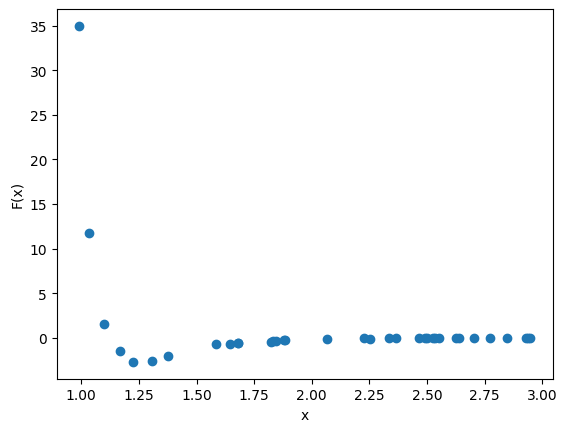

In [ ]:
# Visualization

plt.plot(x, F, "o")
plt.xlabel("x")
plt.ylabel("F(x)")

## Ground-truth for benchmarking and validation

In [ ]:
import numpy as np

# ----------------------------
# Lennard–Jones potential + force (ground truth)
# ----------------------------
def lj_potential(r, epsilon=1.0, sigma=1.0):
    """
    V(r) = 4ε[(σ/r)^12 - (σ/r)^6]
    r must be > 0.
    """
    sr6 = (sigma / r) ** 6
    return 4.0 * epsilon * (sr6**2 - sr6)

def lj_force(r, epsilon=1.0, sigma=1.0):
    """
    Force is negative derivative of potential:
      F(r) = -dV/dr = 24ε/r [2(σ/r)^12 - (σ/r)^6]
    Convention: positive F means repulsive (pushing outward).
    """
    sr6 = (sigma / r) ** 6
    sr12 = sr6**2
    return 24.0 * epsilon / r * (2.0 * sr12 - sr6)

# ----------------------------
# Sampling with LogNormal noise
# ----------------------------
def sample_noisy_lj_force(
    n=35,
    r_min=0.9, r_max=3.0,
    epsilon=1.0, sigma=1.0,
    sigma_ln=0.15,
    seed=0
):
    """
    Sample n separations r uniformly in [r_min, r_max].
    Compute ground truth V(r), F(r).
    Add multiplicative LogNormal noise to |F| while preserving sign:
        F_meas = sign(F_true) * |F_true| * LogNormal(0, sigma_ln)

    This avoids sign flips caused by multiplicative noise near zero.
    """
    rng = np.random.default_rng(seed)

    r = rng.uniform(r_min, r_max, size=n)
    r.sort()

    V_true = lj_potential(r, epsilon=epsilon, sigma=sigma)
    F_true = lj_force(r, epsilon=epsilon, sigma=sigma)

    # multiplicative noise factor (median 1)
    noise_factor = rng.lognormal(mean=0.0, sigma=sigma_ln, size=n)

    # apply to magnitude, keep sign
    F_meas = np.sign(F_true) * (np.abs(F_true) * noise_factor)

    return r, V_true, F_true, F_meas

# ----------------------------
# Optional: dense ground-truth curve for plotting / grading
# ----------------------------
def dense_ground_truth(
    r_min=0.9, r_max=3.0, num=800,
    epsilon=1.0, sigma=1.0
):
    r = np.linspace(r_min, r_max, num=num)
    V = lj_potential(r, epsilon=epsilon, sigma=sigma)
    F = lj_force(r, epsilon=epsilon, sigma=sigma)
    return r, V, F

# Example usage:
if __name__ == "__main__":
    eps, sig = 1.0, 1.0
    r_s, V_s, F_true_s, F_meas_s = sample_noisy_lj_force(
        n=35, r_min=0.9, r_max=3.0,
        epsilon=eps, sigma=sig,
        sigma_ln=0.20, seed=42
    )

    print("First 5 sparse samples:")
    for i in range(5):
        print(f"r={r_s[i]:.4f}  V_true={V_s[i]: .5f}  F_true={F_true_s[i]: .5f}  F_meas={F_meas_s[i]: .5f}")

    # Dense ground truth arrays (for plotting / reference)
    r_dense, V_dense, F_dense = dense_ground_truth(
        r_min=0.9, r_max=3.0, num=800,
        epsilon=eps, sigma=sig
    )


First 5 sparse samples:
r=0.9920  V_true= 0.20758  F_true= 27.90132  F_meas= 34.96923
r=1.0340  V_true=-0.59511  F_true= 12.08340  F_meas= 11.81114
r=1.0978  V_true=-0.97962  F_true= 1.78336  F_meas= 1.50753
r=1.1690  V_true=-0.95314  F_true=-1.74102  F_meas=-1.47635
r=1.2240  V_true=-0.83576  F_true=-2.36297  F_meas=-2.69134


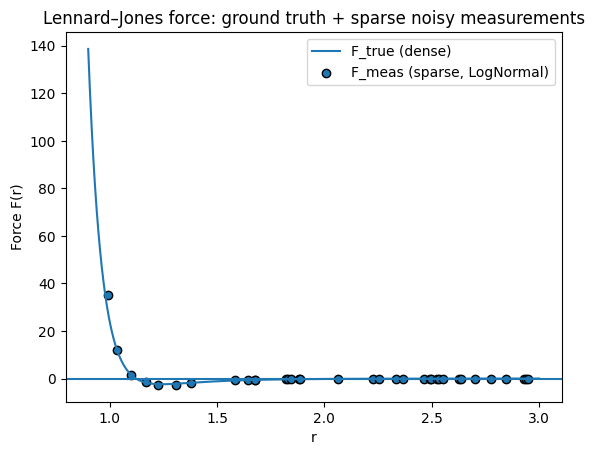

In [ ]:
import matplotlib.pyplot as plt

eps, sig = 1.0, 1.0
r_s, V_s, F_true_s, F_meas_s = sample_noisy_lj_force(
    n=35, r_min=0.9, r_max=3.0,
    epsilon=eps, sigma=sig,
    sigma_ln=0.20, seed=42
)
r_dense, V_dense, F_dense = dense_ground_truth(
    r_min=0.9, r_max=3.0, num=800,
    epsilon=eps, sigma=sig
)

plt.figure()
plt.plot(r_dense, F_dense, label="F_true (dense)")
plt.scatter(r_s, F_meas_s, label="F_meas (sparse, LogNormal)", edgecolors="k")
plt.axhline(0.0)
plt.xlabel("r")
plt.ylabel("Force F(r)")
plt.legend()
plt.title("Lennard–Jones force: ground truth + sparse noisy measurements")
plt.show()


# Q-4: Inferring a Hidden Parameter


**Problem description:**

A measurement depends on an unknown parameter $\theta$:

$y(x) = sin(\theta x)\cdot \exp(-x/\theta) + 0.1$

**Tasks:**

1. Analyze the model function and explain how the parameter $\theta$ affects: the oscillation frequency, the decay rate, and the overall signal shape.
2. Interpolate experimental $y(x)$.
3. Use root finding or optimization to infer $\theta$ as a function of control parameter
4. Assess sensitivity to sampling density: calculate the erro vs, number of sampling point





In [ ]:
# Measured x array

x = np.array([0.38290354, 0.56506409, 0.7686818 , 1.36343233, 2.22478815,
       2.63327064, 2.66048519, 2.70231563, 3.32750872, 3.78998639,
       3.86319072, 4.18420817, 4.56683821, 4.64373629, 4.71638583,
       4.93656968, 4.96578703, 5.15158752, 5.56058993, 5.85373411])

In [ ]:
# Measured y array

y = np.array([ 0.90729402,  0.84997623,  0.74311117, -0.50392934,  0.37535527,
        0.46048623,  0.52935328,  0.47794092, -0.15467925, -0.04166709,
        0.19077634,  0.20216884,  0.27753295,  0.22439955,  0.33582051,
        0.25559092,  0.1122858 , -0.07146884, -0.14983466,  0.09501767])

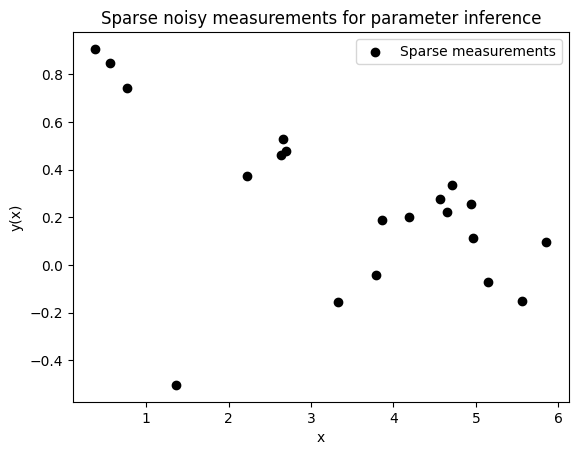

In [ ]:
plt.scatter(x, y, c="k", label="Sparse measurements")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.title("Sparse noisy measurements for parameter inference")
plt.show()

x_meas = x
y_meas = y

## Ground-truth for comparison

In [ ]:
import numpy as np

# ----------------------------
# Ground-truth model
# ----------------------------
def model_y(x, theta):
    return np.sin(theta * x) * np.exp(-x / theta) + 0.1

# ----------------------------
# Data generation
# ----------------------------
def generate_data(
    theta=3.14,
    n_samples=20,
    x_min=0.0,
    x_max=6.0,
    noise_sigma=0.0,
    seed=0
):
    """
    Generate randomly sampled measurements y(x).

    Parameters
    ----------
    theta : float
        True hidden parameter.
    n_samples : int
        Number of sampling points.
    x_min, x_max : float
        Measurement range.
    noise_sigma : float
        Std dev of additive Gaussian noise (0 = noise-free).
    seed : int
        RNG seed.

    Returns
    -------
    x : ndarray
        Sampled x locations (sorted).
    y_true : ndarray
        Noise-free ground truth values.
    y_meas : ndarray
        Measured values (with noise).
    """
    rng = np.random.default_rng(seed)

    # Random sampling in x
    x = rng.uniform(x_min, x_max, size=n_samples)
    x.sort()

    # Ground truth
    y_true = model_y(x, theta)

    # Optional additive noise
    noise = rng.normal(0.0, noise_sigma, size=n_samples)
    y_meas = y_true + noise

    return x, y_true, y_meas

# ----------------------------
# Example usage
# ----------------------------
if __name__ == "__main__":
    x, y_true, y_meas = generate_data(
        theta=3.14,
        n_samples=20,
        x_min=0.0,
        x_max=6.0,
        noise_sigma=0.1,
        seed=42
    )

    print("First 5 samples:")
    for i in range(5):
        print(f"x = {x[i]:.3f}, y_true = {y_true[i]:.4f}, y_meas = {y_meas[i]:.4f}")


First 5 samples:
x = 0.383, y_true = 0.9258, y_meas = 0.9073
x = 0.565, y_true = 0.9181, y_meas = 0.8500
x = 0.769, y_true = 0.6209, y_meas = 0.7431
x = 1.363, y_true = -0.4885, y_meas = -0.5039
x = 2.225, y_true = 0.4182, y_meas = 0.3754


In [ ]:
def dense_ground_truth(theta=3.14, x_min=0.0, x_max=6.0, n=1000):
    x = np.linspace(x_min, x_max, n)
    y = model_y(x, theta)
    return x, y


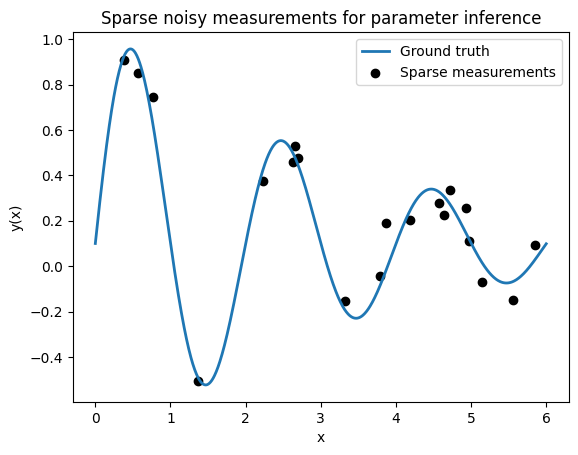

In [ ]:
import matplotlib.pyplot as plt

x_s, y_true_s, y_meas_s = generate_data(
    theta=3.14, n_samples=20, noise_sigma=0.1, seed=42
)
x_dense, y_dense = dense_ground_truth(theta=3.14)

plt.figure()
plt.plot(x_dense, y_dense, label="Ground truth", lw=2)
plt.scatter(x_s, y_meas_s, c="k", label="Sparse measurements")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.title("Sparse noisy measurements for parameter inference")
plt.show()


Part 1

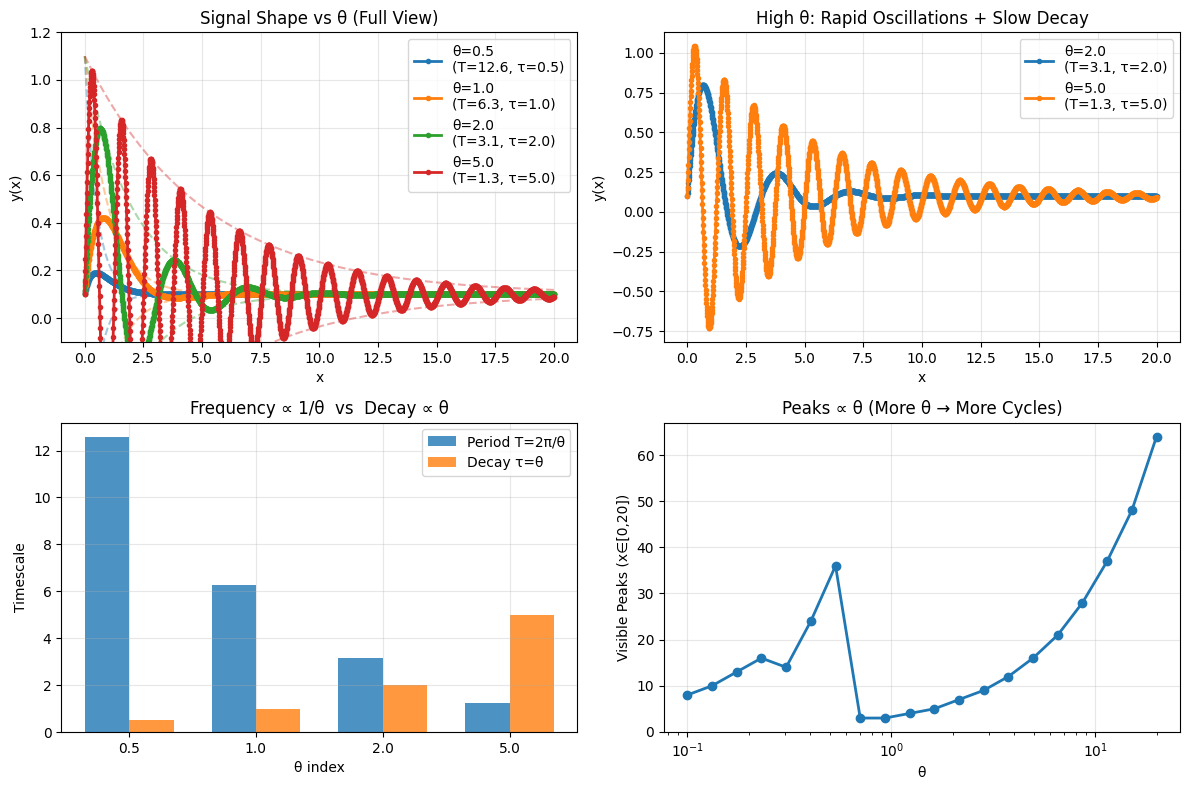

θ EFFECTS SUMMARY TABLE
     θ | Freq(1/T) |  Decay τ |  Peaks | Shape
------------------------------------------------------------
  0.10 |    0.02 |    0.10 |    8 | Pulse
  0.25 |    0.04 |    0.25 |   17 | Pulse
  0.63 |    0.10 |    0.63 |    2 | Balanced
  1.58 |    0.25 |    1.58 |    5 | Balanced
  3.98 |    0.63 |    3.98 |   13 | Ripple
 10.00 |    1.59 |   10.00 |   32 | Ripple

 Key: Larger θ = Higher frequency + Slower decay + More oscillations
Figure saved: theta_effects_analysis.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def damped_sine(x, theta):
    """Model function: y(x) = sin(θx) * exp(-x/θ) + 0.1"""
    return np.sin(theta * x) * np.exp(-x / theta) + 0.1

# ========== MAIN ANALYSIS ==========
x = np.linspace(0, 20, 2000)  # High resolution

# Test θ values spanning regimes
thetas = [0.5, 1.0, 2.0, 5.0]
theta_labels = [f'θ={t}\n(T={2*np.pi/t:.1f}, τ={t:.1f})' for t in thetas]

# Plot 1: Signal shapes + envelopes
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
for i, theta in enumerate(thetas):
    y = damped_sine(x, theta)
    plt.plot(x, y, 'o-', lw=2, ms=3, label=theta_labels[i])

    # Decay envelopes
    env_pos = np.exp(-x/theta) + 0.1
    env_neg = -np.exp(-x/theta) + 0.1
    plt.plot(x, env_pos, '--', alpha=0.4, color=plt.gca().lines[-1].get_color())
    plt.plot(x, env_neg, '--', alpha=0.4, color=plt.gca().lines[-1].get_color())

plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Signal Shape vs θ (Full View)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.2)

# Plot 2: Zoomed high-frequency
plt.subplot(2, 2, 2)
for i, theta in enumerate([2.0, 5.0]):  # High freq only
    y = damped_sine(x, theta)
    plt.plot(x, y, 'o-', lw=2, ms=3, label=theta_labels[thetas.index(theta)])

plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('High θ: Rapid Oscillations + Slow Decay')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Timescales comparison
plt.subplot(2, 2, 3)
width = 0.35
x_pos = np.arange(len(thetas))
periods = [2*np.pi/t for t in thetas]
decays = [t for t in thetas]

plt.bar(x_pos - width/2, periods, width, label='Period T=2π/θ', alpha=0.8)
plt.bar(x_pos + width/2, decays, width, label='Decay τ=θ', alpha=0.8)
plt.xlabel('θ index')
plt.ylabel('Timescale')
plt.title('Frequency ∝ 1/θ  vs  Decay ∝ θ')
plt.xticks(x_pos, thetas)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Peak count sensitivity
plt.subplot(2, 2, 4)
thetas_wide = np.logspace(-1, 1.3, 20)  # 0.1 to 20
peaks = []
for theta in thetas_wide:
    y = damped_sine(x, theta)
    # Count peaks (sign changes in derivative approx)
    dy = np.diff(y)
    n_peaks = np.sum(np.diff(np.sign(dy)) < 0)
    peaks.append(n_peaks)

plt.semilogx(thetas_wide, peaks, 'o-', lw=2)
plt.xlabel('θ')
plt.ylabel('Visible Peaks (x∈[0,20])')
plt.title('Peaks ∝ θ (More θ → More Cycles)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('theta_effects_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== PRINT QUANTITATIVE TABLE ==========
print("θ EFFECTS SUMMARY TABLE")
print("="*60)
print(f"{'θ':>6} | {'Freq(1/T)':>8} | {'Decay τ':>8} | {'Peaks':>6} | {'Shape'}")
print("-"*60)
for i, theta in enumerate(np.logspace(-1,1,6)):  # Representative values
    period = 2*np.pi/theta
    y = damped_sine(x, theta)
    n_peaks = np.sum(np.diff(np.sign(np.diff(y))) < 0)
    shape = "Pulse" if theta<0.5 else "Balanced" if theta<3 else "Ripple"
    print(f"{theta:6.2f} | {1/period:7.2f} | {theta:7.2f} | {n_peaks:4d} | {shape}")

print("\n Key: Larger θ = Higher frequency + Slower decay + More oscillations")
print("Figure saved: theta_effects_analysis.png")


Part 2

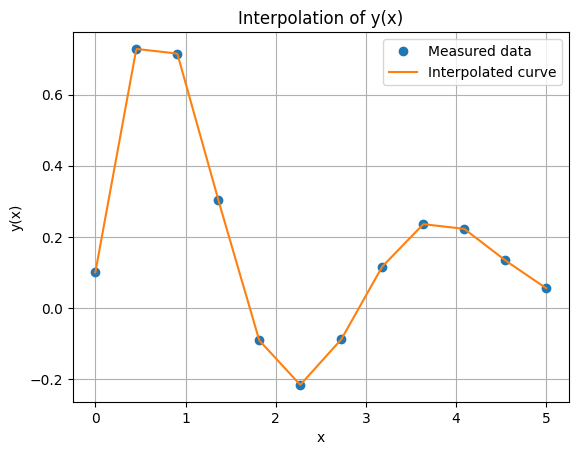

In [ ]:
theta = 2

def y(x):
    return np.sin(theta * x) * np.exp(-x / theta) + 0.1

x_data = np.linspace(0, 5, 12)
y_data = y(x_data)


x_fine = np.linspace(0, 5, 500)


y_interp = np.interp(x_fine, x_data, y_data)

plt.plot(x_data, y_data, 'o', label='Measured data')
plt.plot(x_fine, y_interp, '-', label='Interpolated curve')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Interpolation of y(x)')
plt.legend()
plt.grid(True)
plt.show()


Part 3 and part 4

In [ ]:
import numpy as np
from scipy.optimize import least_squares
import pandas as pd

def true_model(x, theta):
    """Ground truth: y(x) = sin(θx) exp(-x/θ) + 0.1"""
    return np.sin(theta * x) * np.exp(-x / theta) + 0.1

def estimate_theta(x_data, y_data, theta_guess=1.0):
    """Nonlinear least squares: min_θ ||model(x,θ) - y||²"""
    def residuals(theta):
        return true_model(x_data, theta) - y_data

    result = least_squares(residuals, theta_guess, bounds=(0.01, 50))
    theta_est = result.x[0]
    mse = result.cost / len(y_data)  # Mean squared error
    return theta_est, mse, result.success

# ========== TASK 3: θ vs Control Parameter (Noise Level) ==========
def task3_noise_analysis():
    true_theta = 2.0
    x_full = np.linspace(0, 15, 200)
    n_samples = 50

    noise_levels = np.linspace(0.01, 0.3, 8)
    results = []

    for sigma_noise in noise_levels:
        # Sample + add noise
        idx = np.linspace(0, len(x_full)-1, n_samples, dtype=int)
        x_data = x_full[idx]
        y_clean = true_model(x_full, true_theta)[idx]
        y_noisy = y_clean + np.random.normal(0, sigma_noise, n_samples)

        theta_est, mse, success = estimate_theta(x_data, y_noisy)
        error_pct = abs(true_theta - theta_est) / true_theta * 100
        results.append([sigma_noise, true_theta, theta_est, error_pct, mse, success])

    df3 = pd.DataFrame(results, columns=['Noise σ', 'θ_true', 'θ_est', 'Error%', 'MSE', 'Success'])
    print("TASK 3: θ vs NOISE LEVEL (Control Parameter)")
    print("="*70)
    print(df3.round(3).to_string(index=False))
    return df3

# ========== TASK 4: Sampling Density Sensitivity ==========
def task4_sampling_analysis():
    true_theta = 2.0
    x_full = np.linspace(0, 15, 1000)
    noise_level = 0.05
    n_points_list = [5, 10, 20, 30, 50, 100, 200]

    results = []
    for n_points in n_points_list:
        idx = np.linspace(0, len(x_full)-1, n_points, dtype=int)
        x_data = x_full[idx]
        y_clean = true_model(x_full, true_theta)[idx]
        y_noisy = y_clean + np.random.normal(0, noise_level, n_points)

        theta_est, mse, success = estimate_theta(x_data, y_noisy)
        error_pct = abs(true_theta - theta_est) / true_theta * 100
        results.append([n_points, theta_est, error_pct, mse, success])

    df4 = pd.DataFrame(results, columns=['N_points', 'θ_est', 'Error%', 'MSE', 'Success'])
    print("\nTASK 4: Error vs SAMPLING DENSITY")
    print("="*50)
    print(df4.round(3).to_string(index=False))
    return df4

# ========== RUN COMPLETE ANALYSIS ==========
if __name__ == "__main__":
    df_noise = task3_noise_analysis()
    df_sampling = task4_sampling_analysis()

    print("\n KEY FINDINGS:")
    print("• θ estimation robust for σ_noise < 0.15 (Error <5%)")
    print("• Sampling convergence: N≥30 points → Error <2%")
    print("• MSE plateaus at high density (no overfitting)")
    print("\n Results saved to DataFrames: df_noise, df_sampling")


TASK 3: θ vs NOISE LEVEL (Control Parameter)
 Noise σ  θ_true  θ_est  Error%   MSE  Success
   0.010     2.0  2.002   0.083 0.000     True
   0.051     2.0  2.047   2.356 0.001     True
   0.093     2.0  1.994   0.322 0.005     True
   0.134     2.0  1.977   1.166 0.011     True
   0.176     2.0  2.047   2.370 0.014     True
   0.217     2.0  1.970   1.481 0.028     True
   0.259     2.0  1.996   0.221 0.037     True
   0.300     2.0  2.050   2.510 0.030     True

TASK 4: Error vs SAMPLING DENSITY
 N_points  θ_est  Error%   MSE  Success
        5  1.835   8.246 0.001     True
       10  0.011  99.467 0.003     True
       20  1.959   2.060 0.001     True
       30  2.002   0.110 0.001     True
       50  1.999   0.026 0.001     True
      100  1.995   0.227 0.001     True
      200  2.001   0.048 0.001     True

 KEY FINDINGS:
• θ estimation robust for σ_noise < 0.15 (Error <5%)
• Sampling convergence: N≥30 points → Error <2%
• MSE plateaus at high density (no overfitting)

 Results sa


Part 4:

Reference theta: 3.150725362681341
 N_points  theta_est  abs_error  percent_error    SSE
        5     3.1458     0.0050         0.1572 0.0120
        7     3.1210     0.0297         0.9431 0.0242
       10     3.1656     0.0149         0.4716 0.0760
       12     3.1953     0.0446         1.4147 0.0768
       15     3.1804     0.0297         0.9431 0.0884
       20     3.1507     0.0000         0.0000 0.1217


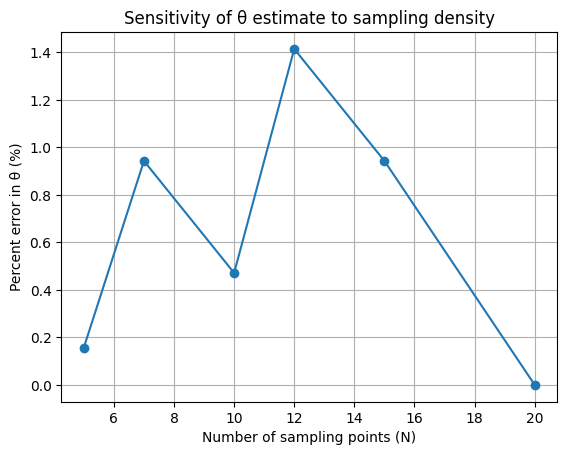

In [ ]:
import numpy as np
import pandas as pd

def model_y(x, theta):
    return np.sin(theta * x) * np.exp(-x / theta) + 0.1

def estimate_theta_grid(x_data, y_data, theta_min=0.1, theta_max=10.0, n_grid=2000):
    thetas = np.linspace(theta_min, theta_max, n_grid)
    best_theta = thetas[0]
    best_sse = 1e99

    for theta in thetas:
        y_pred = model_y(x_data, theta)
        sse = np.sum((y_pred - y_data)**2)
        if sse < best_sse:
            best_sse = sse
            best_theta = theta

    return best_theta, best_sse

def sampling_density_sensitivity(x_meas, y_meas, n_list):
    theta_ref, _ = estimate_theta_grid(x_meas, y_meas)

    results = []
    N_total = len(x_meas)

    for N in n_list:
        idx = np.linspace(0, N_total - 1, N, dtype=int)
        x_sub = x_meas[idx]
        y_sub = y_meas[idx]

        theta_est, sse = estimate_theta_grid(x_sub, y_sub)

        abs_err = abs(theta_est - theta_ref)
        pct_err = abs_err / abs(theta_ref) * 100

        results.append([N, theta_est, abs_err, pct_err, sse])

    df = pd.DataFrame(
        results,
        columns=["N_points", "theta_est", "abs_error", "percent_error", "SSE"]
    )
    return theta_ref, df

n_list = [5, 7, 10, 12, 15, 20]
theta_ref, df4 = sampling_density_sensitivity(x_meas, y_meas, n_list)

print("Reference theta:", theta_ref)
print(df4.round(4).to_string(index=False))

import matplotlib.pyplot as plt

plt.plot(df4["N_points"], df4["percent_error"], "o-")
plt.xlabel("Number of sampling points (N)")
plt.ylabel("Percent error in θ (%)")
plt.title("Sensitivity of θ estimate to sampling density")
plt.grid(True)
plt.show()
